#  Movie Recommendation System

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

##  Data Loading

In [2]:
ratings=pd.read_csv("ratings.csv")
movies=pd.read_csv("movies.csv")

In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [6]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


##  Content-Based Filtering

In [7]:
print("Unique users:",ratings["userId"].nunique())
print("Unique movies rated:",ratings["movieId"].nunique())
print(ratings["rating"].describe())

Unique users: 610
Unique movies rated: 9724
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [8]:
ratings["movieId"].value_counts().head(10)

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
Name: count, dtype: int64

In [9]:
data=pd.merge(ratings,movies,on="movieId")
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [10]:
data.groupby("title")["rating"].count().sort_values(ascending=False).head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64

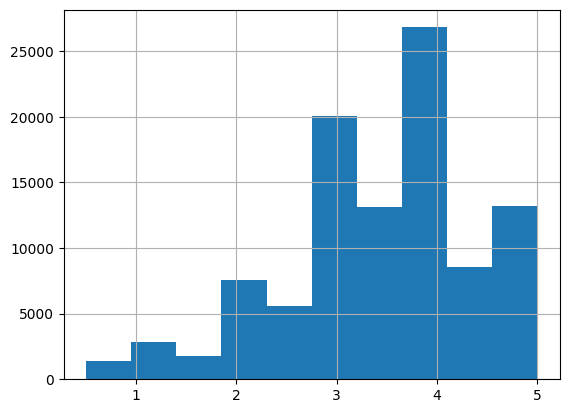

In [11]:
data["rating"].hist()
plt.show()

In [12]:
movie_mean=data.groupby("title")["rating"].mean().sort_values(ascending=False)
movie_mean.head(10)

title
Karlson Returns (1970)                                                         5.0
Zeitgeist: Moving Forward (2011)                                               5.0
Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)    5.0
Dragons: Gift of the Night Fury (2011)                                         5.0
12 Angry Men (1997)                                                            5.0
Justice League: Doom (2012)                                                    5.0
Junior and Karlson (1968)                                                      5.0
Jump In! (2007)                                                                5.0
Human Condition III, The (Ningen no joken III) (1961)                          5.0
Louis Theroux: Law & Disorder (2008)                                           5.0
Name: rating, dtype: float64

In [13]:
movie_count=data.groupby("title")["rating"].count().sort_values(ascending=False)
movie_count.head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64

In [14]:
movie_stats=data.groupby("title")["rating"].agg(["mean","count"])
movie_stats.head(10)

,mean,count
title,,
'71 (2014),4.000000,1
'Hellboy': The Seeds of Creation (2004),4.000000,1
'Round Midnight (1986),3.500000,2
'Salem's Lot (2004),5.000000,1
'Til There Was You (1997),4.000000,2
'Tis the Season for Love (2015),1.500000,1
"'burbs, The (1989)",3.176471,17
'night Mother (1986),3.000000,1
(500) Days of Summer (2009),3.666667,42


In [15]:
movie_stats[movie_stats["count"]>=50].sort_values("mean",ascending=False).head(10)

,mean,count
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


In [16]:
user_movie_matrix=data.pivot_table(index="userId",columns="title",values="rating")
user_movie_matrix.head(10)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


In [17]:
user_movie_matrix.shape

(610, 9719)

In [18]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [19]:
movies["genres"]=movies["genres"].str.split("|")

In [20]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb=MultiLabelBinarizer()
genre_matrix=mlb.fit_transform(movies["genres"])
genre_df=pd.DataFrame(genre_matrix,columns=mlb.classes_)

In [21]:
movies_with_features=pd.concat([movies,genre_df],axis=1)


In [22]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim=cosine_similarity(genre_df)

0=same direction , 90=no relation ,180=opposite

In [23]:
cosine_sim[0]

array([1.        , 0.77459667, 0.31622777, ..., 0.        , 0.31622777,
       0.4472136 ], shape=(9742,))

In [24]:
movies=movies.reset_index() # har movie ka index fix ho jaye

In [25]:
indices=pd.Series(movies.index,index=movies["title"])


In [26]:
indices["Toy Story (1995)"]

np.int64(0)

In [27]:
idx=indices["Toy Story (1995)"]

In [28]:
sim_scores=list(enumerate(cosine_sim[idx]))

In [29]:
sim_scores=sorted(sim_scores,key=lambda x:x[1],reverse=True)

In [30]:
sim_scores[:10]

[(0, np.float64(0.9999999999999999)),
 (1706, np.float64(0.9999999999999999)),
 (2355, np.float64(0.9999999999999999)),
 (2809, np.float64(0.9999999999999999)),
 (3000, np.float64(0.9999999999999999)),
 (3568, np.float64(0.9999999999999999)),
 (6194, np.float64(0.9999999999999999)),
 (6486, np.float64(0.9999999999999999)),
 (6948, np.float64(0.9999999999999999)),
 (7760, np.float64(0.9999999999999999))]

In [31]:
sim_scores=sim_scores[1:6]

In [32]:
movie_indices=[i[0] for i in sim_scores]

In [33]:
movies["title"].iloc[movie_indices]

1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: str

In [34]:
def recommend(title):
    idx=indices[title]
    sim_scores=list(enumerate(cosine_sim[idx]))
    sim_scores=sorted(sim_scores,key=lambda x: x[1],reverse=True)
    sim_scores=sim_scores[1:6]
    movie_indices=[i[0] for i in sim_scores]
    return movies["title"].iloc[movie_indices]

In [35]:
recommend("Toy Story (1995)")


1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: str

In [36]:
recommend("Jumanji (1995)")

53             Indian in the Cupboard, The (1995)
109             NeverEnding Story III, The (1994)
767               Escape to Witch Mountain (1975)
1514    Darby O'Gill and the Little People (1959)
1556                          Return to Oz (1985)
Name: title, dtype: str

In [37]:
recommend("Heat (1995)")

22                      Assassins (1995)
138    Die Hard: With a Vengeance (1995)
156                      Net, The (1995)
249          Natural Born Killers (1994)
417                Judgment Night (1993)
Name: title, dtype: str

In [38]:
recommend("GoldenEye (1995)")

84           Broken Arrow (1996)
378           Cliffhanger (1993)
431    Executive Decision (1996)
479    Surviving the Game (1994)
592             Rock, The (1996)
Name: title, dtype: str

In [39]:
def recommend(title):
    if title not in indices:
        return "Movie not found"
    idx=indices[title]
    sim_scores=list(enumerate(cosine_sim[idx]))
    sim_scores=sorted(sim_scores,key=lambda x:x[1],reverse=True)
    sim_scores=sim_scores[1:6]
    movie_indices=[i[0] for i in sim_scores]
    return movies["title"].iloc[movie_indices]

In [40]:
def recommend(title):
    if title not in indices:
        return "Movie not found"
    idx=indices[title]
    sim_scores=list(enumerate(cosine_sim[idx]))
    sim_scores=sorted(sim_scores,key=lambda x:x[1],reverse=True)
    sim_scores=sim_scores[1:6]
    movie_indices=[i[0] for i in sim_scores]
    scores=[i[1] for i in sim_scores]
    result=pd.DataFrame({"title":movies["title"].iloc[movie_indices].values,"similarity_score":scores})
    return result

In [41]:
recommend("Toy Story (1995)")

,title,similarity_score
0,Antz (1998),1.0
1,Toy Story 2 (1999),1.0
2,"Adventures of Rocky and Bullwinkle, The (2000)",1.0
3,"Emperor's New Groove, The (2000)",1.0
4,"Monsters, Inc. (2001)",1.0


In [42]:
movies["title"].value_counts().head(10)

title
Emma (1996)                               2
Saturn 3 (1980)                           2
Confessions of a Dangerous Mind (2002)    2
Eros (2004)                               2
War of the Worlds (2005)                  2
Toy Story (1995)                          1
Jumanji (1995)                            1
Grumpier Old Men (1995)                   1
Waiting to Exhale (1995)                  1
Father of the Bride Part II (1995)        1
Name: count, dtype: int64

##  Collaborative Filtering

In [43]:
user_movie_matrix=data.pivot_table(index="userId",columns="title",values="rating")

In [44]:
user_movie_matrix_filled=user_movie_matrix.fillna(0)

In [72]:

user_similarity=cosine_similarity(user_movie_matrix_filled)

In [46]:
user_similarity_df=pd.DataFrame(user_similarity,index=user_movie_matrix.index,columns=user_movie_matrix.index)

In [47]:
target_user=1

In [48]:
similar_users=user_similarity_df[target_user].sort_values(ascending=False)[1:6]

In [49]:
user_movies=user_movie_matrix.loc[target_user]
watched_movies=user_movies[user_movies>0].index

In [50]:
candidate_movies=set()
for user in similar_users.index:
    movies=user_movie_matrix.loc[user]
    movies=movies[movies>0].index
    candidate_movies.update(movies)

In [51]:
candidate_movies=candidate_movies-set(watched_movies)

In [52]:
list(candidate_movies)[:5]

['Last Action Hero (1993)',
 'Under Siege (1992)',
 'Exorcist, The (1973)',
 'Iron Eagle IV (1995)',
 'Warriors, The (1979)']

In [53]:
movie_scores={}
for movie in candidate_movies:
    ratings=[]
    for user in similar_users.index:
        rating=user_movie_matrix.loc[user,movie]
        if rating>0:
            ratings.append(rating)
    if ratings:
        movie_scores[movie]=sum(ratings)/len(ratings)
    

In [54]:
ranked_movies=sorted(movie_scores.items(),key=lambda x:x[1],reverse=True)

In [55]:
ranked_movies[:5]

[('Exorcist, The (1973)', np.float64(5.0)),
 ('Phantasm II (1988)', np.float64(5.0)),
 ('Key Largo (1948)', np.float64(5.0)),
 ('Shrek (2001)', np.float64(5.0)),
 ('Hard-Boiled (Lat sau san taam) (1992)', np.float64(5.0))]

In [56]:
movie_scores={}
for movie in candidate_movies:
    ratings_with_similarity=[]
    for user in similar_users.index:
        rating=user_movie_matrix.loc[user,movie]
        similarity=similar_users[user]

        if rating>0:
            ratings_with_similarity.append((rating,similarity))
    if ratings_with_similarity:
        sum_rating_times_sim=0
        sum_sim=0
        for rating,similarity in ratings_with_similarity:
            sum_rating_times_sim+=rating*similarity
            sum_sim+=similarity
        movie_scores[movie]=sum_rating_times_sim/sum_sim

In [57]:
ranked_movies=sorted(movie_scores.items(),key=lambda x:x[1],reverse=True)

In [58]:
ranked_movies[:5]

[('Godfather, The (1972)', np.float64(5.000000000000001)),
 ('Blade Runner (1982)', np.float64(5.000000000000001)),
 ('Exorcist, The (1973)', np.float64(5.0)),
 ('Phantasm II (1988)', np.float64(5.0)),
 ('Key Largo (1948)', np.float64(5.0))]

In [59]:
def score_movies(candidate_movies,similar_users,user_movie_matrix):
    movie_scores={}
    for movie in candidate_movies:
        ratings_with_similarity=[]
        for user in similar_users.index:
            rating=user_movie_matrix.loc[user,movie]
            similarity=similar_users[user]

            if rating>0:
                ratings_with_similarity.append((rating,similarity))
        if ratings_with_similarity:
            sum_rating_times_sim=0
            sum_sim=0
            for rating,similarity in ratings_with_similarity:
                sum_rating_times_sim+=rating*similarity
                sum_sim+=similarity
            movie_scores[movie]=sum_rating_times_sim/sum_sim
    return movie_scores

In [60]:
movie_scores=score_movies(candidate_movies,similar_users,user_movie_matrix)

In [61]:
ranked_movies=sorted(movie_scores.items(),key=lambda x:x[1],reverse=True)
ranked_movies[:5]

[('Godfather, The (1972)', np.float64(5.000000000000001)),
 ('Blade Runner (1982)', np.float64(5.000000000000001)),
 ('Exorcist, The (1973)', np.float64(5.0)),
 ('Phantasm II (1988)', np.float64(5.0)),
 ('Key Largo (1948)', np.float64(5.0))]

In [62]:
def rank_movies(movie_scores,top_n=5):
    n_available=len(movie_scores)
    if top_n>n_available:
        top_n=n_available
    ranked_pairs=sorted(movie_scores.items(),key=lambda x:x[1],reverse=True)
    top_pairs=ranked_pairs[:top_n]
    recommendations=[pair[0] for pair in top_pairs]
    return recommendations

In [63]:
top_recs=rank_movies(movie_scores,top_n=5)
print(top_recs)

['Godfather, The (1972)', 'Blade Runner (1982)', 'Exorcist, The (1973)', 'Phantasm II (1988)', 'Key Largo (1948)']


In [64]:
def get_similar_users(user_similarity_df,target_user,top_k=5):
    similar_users=user_similarity_df[target_user].sort_values(ascending=False)
    return similar_users[1:top_k+1]

In [65]:
def get_candidate_movies(user_movie_matrix,similar_users,target_user):
    user_movies=user_movie_matrix.loc[target_user]
    watched_movies=user_movies[user_movies>0].index
    candidate_movies=set()

    for user in similar_users.index:
        movies=user_movie_matrix.loc[user]
        movies=movies[movies>0].index
        candidate_movies.update(movies)
    candidate_movies=candidate_movies-set(watched_movies)
    return candidate_movies

##  Recommendation Logic

In [66]:
def recommend_movies(user_similarity_df,user_movie_matrix,target_user,top_k=5,top_n=5):
    similar_users=get_similar_users(user_similarity_df,target_user,top_k)
    candidate_movies=get_candidate_movies(user_movie_matrix,similar_users,target_user)
    movie_scores=score_movies(candidate_movies,similar_users,user_movie_matrix)
    recommendations=rank_movies(movie_scores,top_n)
    return recommendations

##  Results

In [67]:
target_user=1
top_k=5
top_n=5
similar_users=get_similar_users(user_similarity_df,target_user,top_k)
print("Similar Users:")
print(similar_users)
candidate_movies=get_candidate_movies(user_movie_matrix,similar_users,target_user)
print("\nCandidate Movies:")
print(candidate_movies)
movie_scores=score_movies(candidate_movies,similar_users,user_movie_matrix)
print("\nMovie Scores:")
print(movie_scores)
ranked_movies=rank_movies(movie_scores,top_n)
print("\nRanked Movies:")
print(ranked_movies)

Similar Users:
userId
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
Name: 1, dtype: float64

Candidate Movies:
{'Last Action Hero (1993)', 'Under Siege (1992)', 'Exorcist, The (1973)', 'Iron Eagle IV (1995)', 'Warriors, The (1979)', 'Thomas Crown Affair, The (1999)', 'Aliens (1986)', "Cutter's Way (1981)", "Devil's Playground (2002)", 'Phantasm II (1988)', 'Misery (1990)', 'Casper (1995)', 'Crumb (1994)', 'Rocky V (1990)', 'Licence to Kill (1989)', 'Decade Under the Influence, A (2003)', 'Doctor Dolittle (1967)', 'Femme Nikita, La (Nikita) (1990)', 'Key Largo (1948)', 'Odd Couple, The (1968)', 'Others, The (2001)', 'Strangeland (1998)', '7th Voyage of Sinbad, The (1958)', 'Monsieur Verdoux (1947)', 'Aces: Iron Eagle III (1992)', 'Big Hit, The (1998)', 'Lord of the Rings: The Return of the King, The (2003)', 'Traffic (2000)', 'Battle for the Planet of the Apes (1973)', 'Young Guns (1988)', 'Powder (1995)', 'Bowling for Columbine (2002)', 'Terminator 2: 

In [68]:
recommendations=recommend_movies(user_similarity_df,user_movie_matrix,target_user,top_k=5,top_n=5)
print(recommendations)

['Godfather, The (1972)', 'Blade Runner (1982)', 'Exorcist, The (1973)', 'Phantasm II (1988)', 'Key Largo (1948)']
